In [332]:
import torch
from torch import nn
import torch.optim as optim

%matplotlib inline
torch.set_printoptions(sci_mode=False,precision=4)
torch.manual_seed(1234)
torch.random.manual_seed(1234)
generator = torch.Generator().manual_seed(1234)

In [333]:
context_length = 3
batch_size = 9
embd_dim = 2
iteration_count = 200
head_size = 2

In [334]:
# m -> 1, 2, 5, 6, 9
# f -> 3, 4, 7, 8
x_numpy = ['b1m','m2b','g3f','f4g','m5b','b6m','g7f','b9m','f8g']
y_numpy = ['C','C','B','B','C','C','B','C','B']

In [4]:
unique_text = list(sorted(set(''.join(x_numpy))))

unique_y_text = ['B', 'C']

VOCAB_INPUT_SIZE = len(unique_text)
print(VOCAB_INPUT_SIZE)

label_vocab = sorted(set(y_numpy))
VOCAB_OUTPUT_SIZE = len(unique_y_text)

13


In [5]:
stoi = {text: index for index, text in enumerate(unique_text)}
itos = {index: text for index, text in enumerate(unique_text)}

encoder = lambda char_array: [stoi[char] for char in ''.join(char_array)]
decoder = lambda num_array: [itos[num] for num in num_array]

In [6]:
x_train = []
y_train = []

for x,y in zip(x_numpy,y_numpy):
    x_train.append(encoder(x))
    y_train.append(0 if y == 'B' else 1)

x_train = torch.tensor(x_train)
y_train = torch.tensor(y_train)

# print(x_train.shape)
# print(y_train.shape)

In [7]:
criterion = nn.CrossEntropyLoss()
embedding = nn.Embedding(VOCAB_INPUT_SIZE, embd_dim) # Assuming vocab_size is defined
pos_embedding = nn.Embedding(context_length, embd_dim)
key = nn.Linear(embd_dim, head_size, bias=False)
query = nn.Linear(embd_dim, head_size, bias=False)
value = nn.Linear(embd_dim, head_size, bias=False)
logit_layer = nn.Linear(head_size * context_length, VOCAB_OUTPUT_SIZE) # Adjusted input size

In [8]:
# --- Optimizer ---
# Note: embedding and logit_layer should be in .train() mode for training
optimizer = optim.Adam([
    {'params': list(embedding.parameters()), 'lr': 0.01},
    {'params': list(pos_embedding.parameters()), 'lr': 0.01}, # Add this
    {'params': list(key.parameters()), 'lr': 0.001},
    {'params': list(query.parameters()), 'lr': 0.001},
    {'params': list(value.parameters()), 'lr': 0.001},
    {'params': list(logit_layer.parameters()), 'lr': 0.001}
], lr=0.001)
tril = torch.tril(torch.ones(context_length, context_length))

In [10]:
print(x_train)
print(y_train)
tok_emb = embedding(x_train)
print(tok_emb.shape)

tensor([[ 9,  0, 12],
        [12,  1,  9],
        [11,  2, 10],
        [10,  3, 11],
        [12,  4,  9],
        [ 9,  5, 12],
        [11,  6, 10],
        [ 9,  8, 12],
        [10,  7, 11]])
tensor([1, 1, 0, 0, 1, 1, 0, 1, 0])
torch.Size([9, 3, 2])


In [ ]:
print(embedding.weight)
print(pos_embedding.weight)
print(key.weight)
print(query.weight)
print(value.weight)
print(logit_layer.weight)

Parameter containing:
tensor([[ 1.4907, -2.1675],
        [ 1.6880, -2.8888],
        [-1.7232,  2.9893],
        [-1.5428,  1.9347],
        [ 1.8235, -1.5549],
        [ 0.5899, -2.3512],
        [ 1.3437,  2.0366],
        [ 4.3056,  2.3373],
        [ 0.6539, -1.3159],
        [-1.6069,  0.7908],
        [ 0.4585, -0.7186],
        [ 1.4191, -0.5310],
        [-0.5503,  1.6320]], requires_grad=True)
0.0063183922320604324


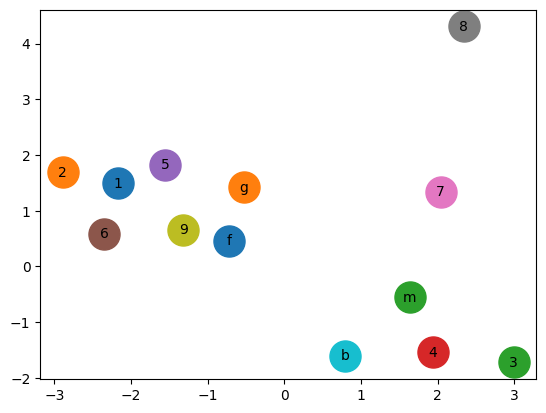

In [331]:
for epoch in range(1):
    # 1. Data Fetching
    optimizer.zero_grad(set_to_none=True)

    tok_emb = embedding(x_train)
    pos = torch.arange(3)
    pos_emb = pos_embedding(pos)
    x = tok_emb + pos_emb

    k = key(x)   # (B, T, head_size)
    q = query(x) # (B, T, head_size)


    wei = q @ k.transpose(-2, -1) * (head_size**-0.5) # Scaled dot-product
    wei = wei.masked_fill(tril == 0, float('-inf'))
    wei = torch.nn.functional.softmax(wei, dim=-1)

    v = value(x) # (B, T, head_size)
    out = wei @ v # (B, T, head_size)

    out_flattened = out.view(batch_size, -1)

    logits = logit_layer(out_flattened)
    loss = criterion(logits, y_train)

    if epoch % 10 == 0:
        print(embedding.weight)
        print(loss.item())

    loss.backward()
    optimizer.step()



import matplotlib.pyplot as plt
%matplotlib inline
first = embedding.weight[:, 1].detach().float().cpu().numpy()
second = embedding.weight[:, 0].detach().float().cpu().numpy()
for i in range(len(first)):
    word = itos[i]
    plt.scatter(first[i], second[i], s=500)
    plt.text(first[i], second[i], word, fontsize=10, ha='center', va='center')

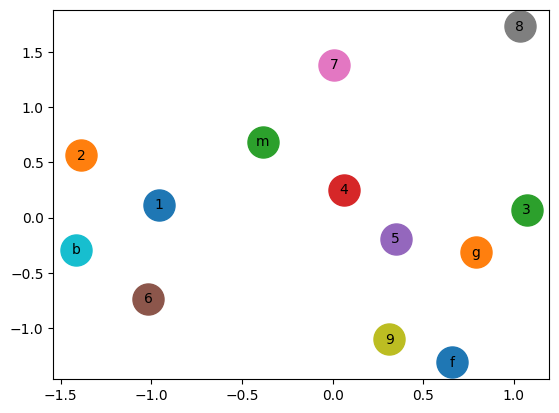

In [431]:
import matplotlib.pyplot as plt
%matplotlib inline
first = embedding.weight[:, 1].detach().float().cpu().numpy()
second = embedding.weight[:, 0].detach().float().cpu().numpy()
for i in range(len(first)):
    word = itos[i]
    plt.scatter(first[i], second[i], s=500)
    plt.text(first[i], second[i], word, fontsize=10, ha='center', va='center')

In [ ]:
#Test
torch.set_printoptions(sci_mode=False, precision=2, threshold=float('inf'))
print(stoi)
logging = True
final_text = "b2m"
for _ in range(1):
        T = 3
        x = torch.tensor(encoder(final_text[-context_length:]))
        print(x.shape)
        x = torch.unsqueeze(x, 0)
        tok_emb = embedding(x) # (B, T, Embd_Size)
        # print('tok_emb.shape : ', tok_emb.shape)

        pos = torch.arange(T, device=x.device)
        pos_emb = pos_embedding(pos)
        x = tok_emb + pos_emb

        # 2. Self-Attention (Must match training logic exactly)
        k = key(x)   # (B, T, head_size)

        # print('k 1 : ', k)
        q = query(x) # (B, T, head_size)

        # print('q 1 : ', q)
        # Calculate attention scores
        # Note: 'tril' should be accessible globally or passed in
        wei = (q @ k.transpose(-2, -1)) * (k.size(-1)**-0.5)
        # Use a local mask in case T varies
        mask = torch.tril(torch.ones(T, T)).to(x.device)
        wei = wei.masked_fill(mask == 0, float('-inf'))

        # print('Wei 1 : ', wei)

        wei = torch.nn.functional.softmax(wei, dim=-1)

        # print('Wei 2 : ', wei)
        # wei = torch.tensor([[[1.00, 0.00, 0.00],
        #  [0.74, 0.26, 0.00],
        #  [0.66, 0.16, 0.18]]])
        # Apply weights to values
        v = value(x)
        #

        # print(v)
        out = wei @ v # (B, T, head_size)

        # print('K : ', key.weight)
        # print('Q : ', query.weight)
        print('WEI : ', wei)



        # print('out: ', out)

        # print(out)
        # 3. Flatten and get Logits
        # Ensure this view matches the shape used in training
        out_flattened = out.reshape(out.size(0), -1)
        logits = logit_layer(out_flattened)
        print('logits : ', logits)

# print(logit_layer.weight.size())
print(final_text)
#pox o'' yo